In [46]:
from pathlib import Path

script = Path(
    "/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/"
    "scripts/05_track_motion.py"
)

text = script.read_text()

print("Step-5 script verification")
print("=" * 55)

print("Exists:", script.exists())
print("Size:", script.stat().st_size, "bytes")

checks = {
    "LV tracking code": "LV TRACKING USING SAME DEFORMATION FIELDS" in text,
    "RV sequence": "RV_fr??.vtk" in text,
    "LV sequence": "LV_fr??.vtk" in text,
    "MIRTK setup": "mirtk" in text,
    "Library setup": "LD_LIBRARY_PATH" in text,
    "20 LV check": "Expected 20 LV frames" in text,
    "20 RV check": "Expected 20 RV frames" in text,
    "40 mesh output": "Total tracked meshes: 40" in text,
}

for name, passed in checks.items():
    print(f"{name:25s}: {'PASS' if passed else 'FAIL'}")

if all(checks.values()):
    print("\n" + "=" * 55)
    print("PASS: UPDATED STEP 5 SCRIPT IS READY")
    print("=" * 55)
else:
    print("\nWARNING: One or more checks failed.")

Step-5 script verification
Exists: True
Size: 7160 bytes
LV tracking code         : PASS
RV sequence              : PASS
LV sequence              : PASS
MIRTK setup              : PASS
Library setup            : PASS
20 LV check              : PASS
20 RV check              : PASS
40 mesh output           : PASS

PASS: UPDATED STEP 5 SCRIPT IS READY


In [1]:
from pathlib import Path
import os
import sys

ROOT = Path("/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN")
os.chdir(ROOT)

print("Cardiac Motion Tracking — Summer School Lab")
print("=" * 55)
print("Working directory:", Path.cwd())
print("Python:", sys.executable)

print("\nPipeline:")
print("1. Check 4D cardiac cine MRI")
print("2. Segment cardiac anatomy")
print("3. Refine segmentation")
print("4. Generate 3D cardiac mesh")
print("5. Track mesh through the cardiac cycle")
print("6. Visualize cardiac motion")

Cardiac Motion Tracking — Summer School Lab
Working directory: /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN
Python: /home/aqayyum/miniconda3/envs/cardiac_motion/bin/python

Pipeline:
1. Check 4D cardiac cine MRI
2. Segment cardiac anatomy
3. Refine segmentation
4. Generate 3D cardiac mesh
5. Track mesh through the cardiac cycle
6. Visualize cardiac motion


In [3]:
%pip install nibabel matplotlib

  Using cached nibabel-5.4.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (125 kB)
  Using cached kiwisolver-1.5.1-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached nibabel-5.4.2-py3-none-any.whl (3.3 MB)
Using cached matplotlib-3.10.9-c

Input: /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/example_20frames/example_subject/cine.nii.gz
Exists: True
Cine shape: (512, 512, 14, 20)
Voxel size: (np.float32(0.9375), np.float32(0.9375), np.float32(8.00007), np.float32(0.003581))
Intensity range: 0.0 to 1472.1914672851562
Number of cardiac frames: 20


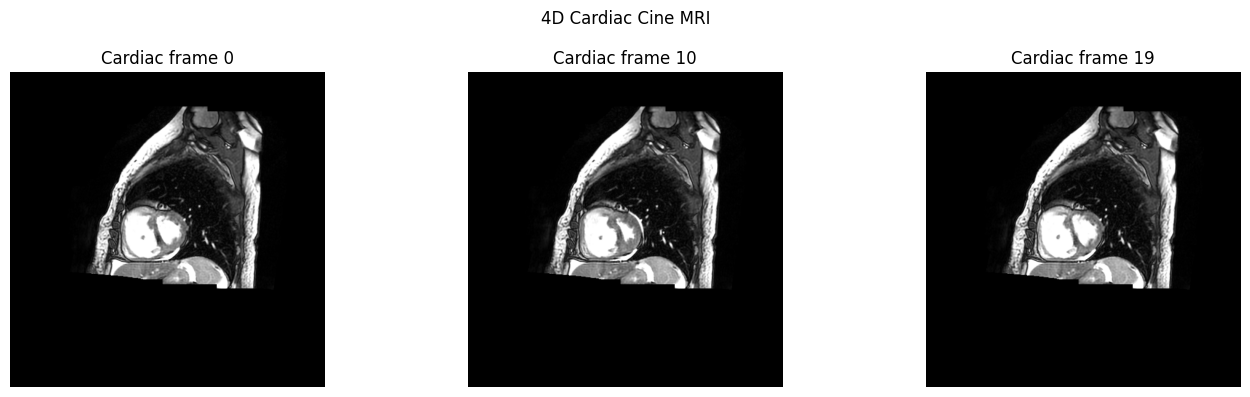

In [4]:
from pathlib import Path
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

CINE = ROOT / "example_20frames" / "example_subject" / "cine.nii.gz"

print("Input:", CINE)
print("Exists:", CINE.exists())

cine_img = nib.load(str(CINE))
cine = cine_img.get_fdata()

print("Cine shape:", cine.shape)
print("Voxel size:", cine_img.header.get_zooms())
print("Intensity range:", float(cine.min()), "to", float(cine.max()))

# Number of cardiac frames
n_frames = cine.shape[-1]
print("Number of cardiac frames:", n_frames)

# Show the middle slice at three cardiac phases
z = cine.shape[2] // 2
frames = [0, n_frames // 2, n_frames - 1]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, t in zip(axes, frames):
    ax.imshow(cine[:, :, z, t].T, cmap="gray", origin="lower")
    ax.set_title(f"Cardiac frame {t}")
    ax.axis("off")

plt.suptitle("4D Cardiac Cine MRI")
plt.tight_layout()
plt.show()

Segmentation: /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/example_20frames/subject_1_ED_seg.nii.gz
Shape: (512, 512, 14)
Labels: [0. 1. 2. 3. 4.]


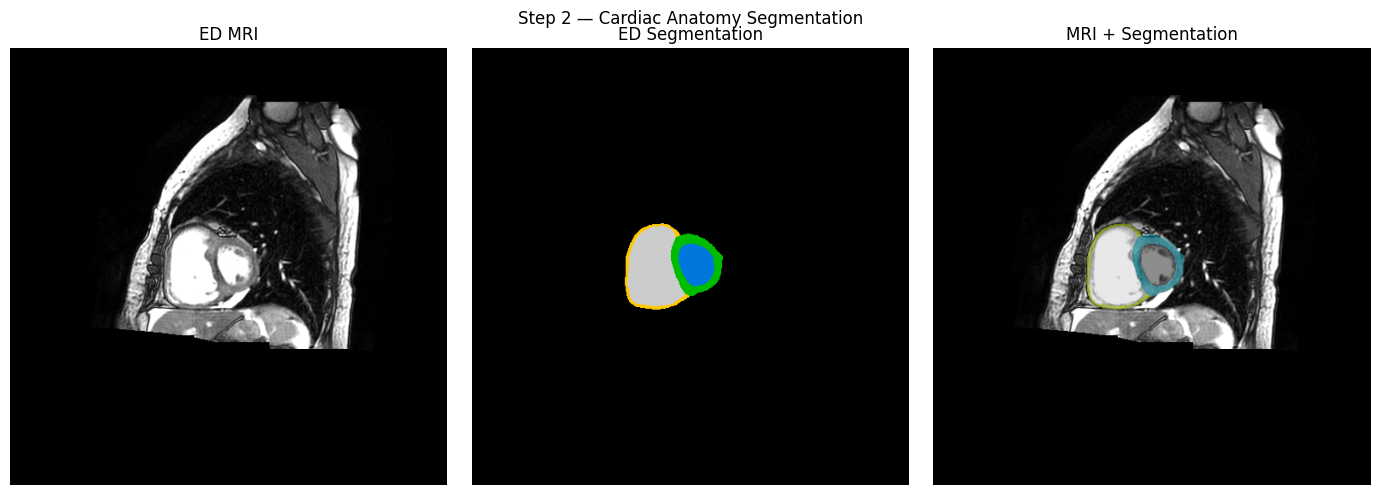

In [5]:
# STEP 3 — Cardiac segmentation at end-diastole (ED)

SEG = ROOT / "example_20frames" / "subject_1_ED_seg.nii.gz"

seg_img = nib.load(str(SEG))
seg = seg_img.get_fdata()

print("Segmentation:", SEG)
print("Shape:", seg.shape)
print("Labels:", np.unique(seg))

# Find a slice containing the largest amount of labelled anatomy
label_voxels = np.sum(seg > 0, axis=(0, 1))
z_seg = int(np.argmax(label_voxels))

# ED = first cardiac frame
ed = cine[:, :, :, 0]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(ed[:, :, z_seg].T, cmap="gray", origin="lower")
axes[0].set_title("ED MRI")
axes[0].axis("off")

axes[1].imshow(seg[:, :, z_seg].T, cmap="nipy_spectral", origin="lower")
axes[1].set_title("ED Segmentation")
axes[1].axis("off")

axes[2].imshow(ed[:, :, z_seg].T, cmap="gray", origin="lower")
axes[2].imshow(
    np.ma.masked_where(seg[:, :, z_seg].T == 0,
                       seg[:, :, z_seg].T),
    cmap="nipy_spectral",
    alpha=0.45,
    origin="lower"
)
axes[2].set_title("MRI + Segmentation")
axes[2].axis("off")

plt.suptitle("Step 2 — Cardiac Anatomy Segmentation")
plt.tight_layout()
plt.show()

In [7]:
#!sed -n '1,240p' scripts/03_refine.py

## Step 3 — Refine the Cardiac Segmentation

The initial ED/ES segmentations are refined using the original 4Dsegment
3-D multi-atlas registration pipeline.

The refinement stage:

1. Takes the ED and ES cardiac MRI volumes.
2. Takes their initial segmentations.
3. Performs 3-D multi-atlas registration.
4. Produces refined ED and ES segmentations.
5. These refined segmentations are subsequently converted into 3-D meshes.

For the summer-school practical, we do not rerun the complete
multi-atlas registration because it is computationally expensive and
uses the legacy Python-2 pipeline.

Instead, we inspect the prepared refined segmentation and continue to
mesh generation.

In [8]:
from pathlib import Path

ROOT = Path("/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN")

results = ROOT / "results"

print("Searching for prepared refined segmentations...\n")

patterns = [
    "**/3D_segmentation_ED.nii.gz",
    "**/3D_segmentation_ES.nii.gz",
    "**/PHsegmentation_ED.gipl",
    "**/PHsegmentation_ES.gipl",
]

found = []

for pattern in patterns:
    matches = list(results.glob(pattern))
    for f in matches:
        print(f)
        found.append(f)

print("\nTotal refinement files found:", len(found))

Searching for prepared refined segmentations...

/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/refinement/3D_segmentation_ED.nii.gz
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/work/subject_1/sizes/3D_segmentation_ED.nii.gz
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/refinement/3D_segmentation_ES.nii.gz
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/work/subject_1/sizes/3D_segmentation_ES.nii.gz
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/work/subject_1/PHsegmentation_ED.gipl
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/work/subject_1/PHsegmentation_ES.gipl

Total refinement files found: 6


In [10]:
#!sed -n '1,260p' scripts/04_create_mesh.py

## Step 4 — Generate the 3-D Cardiac Mesh

The refined 3-D segmentations are converted into template-corresponded
cardiac surface meshes.

The mesh-fitting stage uses:

- Refined ED and ES segmentations
- A cardiac mesh-fitting template
- Registration-based mesh fitting

It produces corresponding meshes for:

- LV endocardium
- LV epicardium
- RV

at both **end-diastole (ED)** and **end-systole (ES)**.

Template correspondence is important because the same mesh vertices can
then be followed through the cardiac cycle.

For the practical session, the computationally expensive legacy
mesh-fitting stage has already been run. We inspect the resulting meshes
and use them for motion tracking.

In [11]:
from pathlib import Path

ROOT = Path("/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN")
MESH_DIR = ROOT / "results" / "subject_1" / "mesh"

print("Step 4 — Prepared cardiac meshes")
print("=" * 55)
print("Mesh directory:", MESH_DIR)
print()

expected_meshes = [
    "F_LVendo_ED.vtk",
    "F_LVendo_ES.vtk",
    "F_LVepi_ED.vtk",
    "F_LVepi_ES.vtk",
    "C_RV_ED.vtk",
    "C_RV_ES.vtk",
]

for name in expected_meshes:
    path = MESH_DIR / name
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{status:8s}  {name}")

Step 4 — Prepared cardiac meshes
Mesh directory: /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/mesh

FOUND     F_LVendo_ED.vtk
FOUND     F_LVendo_ES.vtk
FOUND     F_LVepi_ED.vtk
FOUND     F_LVepi_ES.vtk
FOUND     C_RV_ED.vtk
FOUND     C_RV_ES.vtk


In [12]:
try:
    import pyvista as pv
    print("PyVista version:", pv.__version__)
    print("PASS: PyVista is ready")
except ImportError:
    print("PyVista is not installed")

PyVista is not installed


In [13]:
import sys
!{sys.executable} -m pip install pyvista

  Using cached pyvista-0.49.0-py3-none-any.whl.metadata (14 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached pyvista_validation-0.2.2-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.7 kB)
  Using cached scooby-0.12.0-py3-none-any.whl.metadata (16 kB)
  Using cached docstring_parser-0.18.0-py3-none-any.whl.metadata (3.5 kB)
  Using cached rich_rst-2.2.0-py3-none-any.whl.metadata (5.0 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached pyvista-0.49.0-py3-none-any.whl (2.7 MB)
Using cached pyvista_validation-0.2.2-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (261 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 MB 103.0 MB/s  0:00:010:00:0100:01
Using cached docstring_parser-0.18.0-py3-none-any.whl (22 kB)
Using c

In [14]:
import pyvista as pv

print("PyVista version:", pv.__version__)
print("PASS: PyVista is ready")

PyVista version: 0.49.0
PASS: PyVista is ready


Mesh: F_LVendo_ED.vtk
Vertices: 21510
Cells: 43016


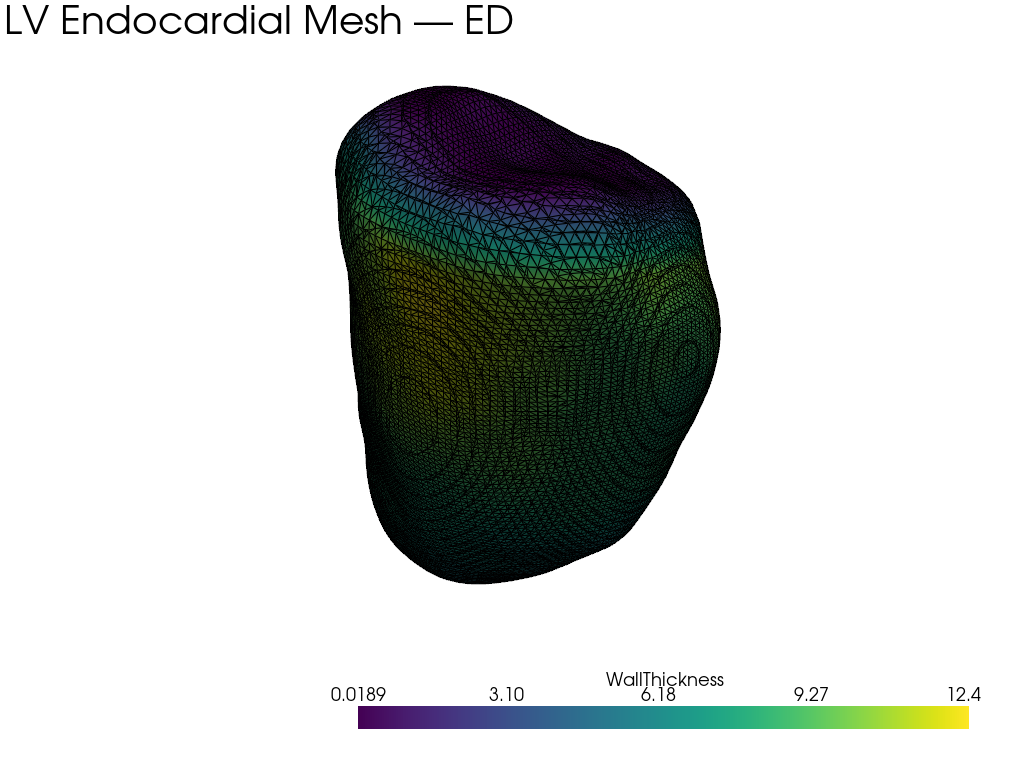

In [15]:
from pathlib import Path
import pyvista as pv

mesh_file = Path(
    "/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/"
    "results/subject_1/mesh/F_LVendo_ED.vtk"
)

mesh = pv.read(mesh_file)

print("Mesh:", mesh_file.name)
print("Vertices:", mesh.n_points)
print("Cells:", mesh.n_cells)

pv.set_jupyter_backend("static")

p = pv.Plotter(notebook=True)
p.add_mesh(mesh, show_edges=True)
p.add_text("LV Endocardial Mesh — ED")
p.show()

In [17]:
#!sed -n '1,320p' scripts/05_track_motion.py

## Step 5 — Track Cardiac Motion Through the Cine Sequence

The fitted cardiac mesh provides a reference anatomical surface.

Motion estimation then uses the **4-D cine MRI sequence** to estimate how
the cardiac anatomy deforms over time.

Conceptually:

**Reference mesh → image registration → deformation field → move mesh vertices → next cardiac frame**

The same mesh topology is retained while its vertex positions change.

Therefore, for every cardiac phase we obtain a corresponding mesh:

`RV_fr00 → RV_fr01 → RV_fr02 → ... → RV_fr19`

Because corresponding vertices represent the same locations on the
cardiac surface, their trajectories can be used to study cardiac motion
throughout the full cardiac cycle.

For this practical, the computationally expensive motion-registration
stage has already been performed.

In [18]:
from pathlib import Path

ROOT = Path(
    "/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN"
)

MOTION_DIR = ROOT / "results" / "subject_1" / "motion"

motion_files = sorted(MOTION_DIR.glob("RV_fr??.vtk"))

print("Step 5 — Cardiac motion tracking")
print("=" * 55)
print("Motion directory:", MOTION_DIR)
print("Number of tracked frames:", len(motion_files))
print()

for f in motion_files:
    print(f.name)

Step 5 — Cardiac motion tracking
Motion directory: /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/motion
Number of tracked frames: 20

RV_fr00.vtk
RV_fr01.vtk
RV_fr02.vtk
RV_fr03.vtk
RV_fr04.vtk
RV_fr05.vtk
RV_fr06.vtk
RV_fr07.vtk
RV_fr08.vtk
RV_fr09.vtk
RV_fr10.vtk
RV_fr11.vtk
RV_fr12.vtk
RV_fr13.vtk
RV_fr14.vtk
RV_fr15.vtk
RV_fr16.vtk
RV_fr17.vtk
RV_fr18.vtk
RV_fr19.vtk


In [19]:
import pyvista as pv
import numpy as np

meshes = [pv.read(str(f)) for f in motion_files]

print("Number of motion meshes:", len(meshes))
print("Vertices per frame:", [m.n_points for m in meshes])
print("Cells per frame:", [m.n_cells for m in meshes])

reference = meshes[0].points

print("\nDisplacement relative to Frame 00")
print("=" * 45)

for i, mesh in enumerate(meshes):
    d = np.linalg.norm(mesh.points - reference, axis=1)

    print(
        f"Frame {i:02d}: "
        f"mean = {d.mean():.3f} mm | "
        f"max = {d.max():.3f} mm"
    )

Number of motion meshes: 20
Vertices per frame: [18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028, 18028]
Cells per frame: [36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052, 36052]

Displacement relative to Frame 00
Frame 00: mean = 0.000 mm | max = 0.000 mm
Frame 01: mean = 1.029 mm | max = 2.941 mm
Frame 02: mean = 2.291 mm | max = 5.465 mm
Frame 03: mean = 3.330 mm | max = 9.002 mm
Frame 04: mean = 3.856 mm | max = 9.175 mm
Frame 05: mean = 4.412 mm | max = 10.623 mm
Frame 06: mean = 4.500 mm | max = 11.642 mm
Frame 07: mean = 4.893 mm | max = 12.877 mm
Frame 08: mean = 4.054 mm | max = 9.407 mm
Frame 09: mean = 4.091 mm | max = 9.485 mm
Frame 10: mean = 3.207 mm | max = 7.145 mm
Frame 11: mean = 2.565 mm | max = 6.488 mm
Frame 12: mean = 2.197 mm | max = 6.042 mm
Frame 13: mean = 1.896 mm | max = 6.376 mm
Frame 14: mea

## Step 6 — Visualize Cardiac Motion

We now have 20 corresponding RV surface meshes representing the
20 cardiac phases.

Each mesh contains the same:

- 18,028 vertices
- 36,052 surface cells

The mesh topology remains fixed while the vertex coordinates change.

Therefore, each vertex can be followed through time:

**Frame 00 → Frame 01 → ... → Frame 19**

This allows us to visualize and quantify cardiac motion over the
complete cardiac cycle.

For visualization, displacement is calculated relative to Frame 00:

\[
d_i(t)=\|x_i(t)-x_i(0)\|
\]

where \(x_i(t)\) is the 3-D position of vertex \(i\) at cardiac
frame \(t\).

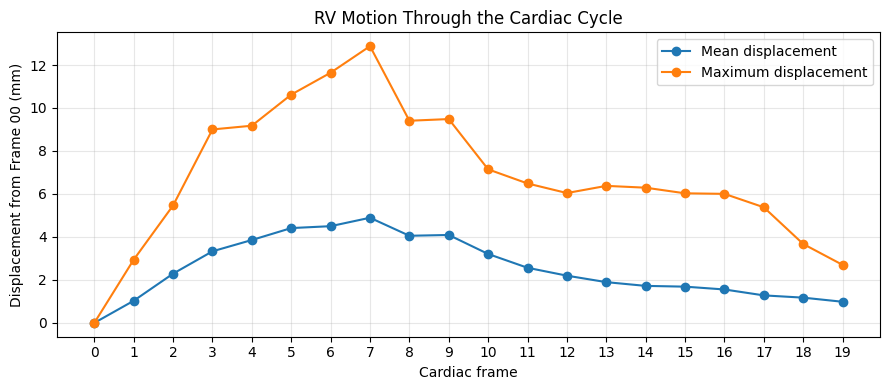

Largest mean displacement:
Frame 07: 4.893 mm


In [20]:
import numpy as np
import matplotlib.pyplot as plt

reference = meshes[0].points

mean_disp = []
max_disp = []

for mesh in meshes:
    d = np.linalg.norm(mesh.points - reference, axis=1)
    mean_disp.append(d.mean())
    max_disp.append(d.max())

frames = np.arange(len(meshes))

plt.figure(figsize=(9, 4))

plt.plot(
    frames,
    mean_disp,
    marker="o",
    label="Mean displacement"
)

plt.plot(
    frames,
    max_disp,
    marker="o",
    label="Maximum displacement"
)

plt.xlabel("Cardiac frame")
plt.ylabel("Displacement from Frame 00 (mm)")
plt.title("RV Motion Through the Cardiac Cycle")
plt.xticks(frames)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

peak = int(np.argmax(mean_disp))

print("Largest mean displacement:")
print(f"Frame {peak:02d}: {mean_disp[peak]:.3f} mm")

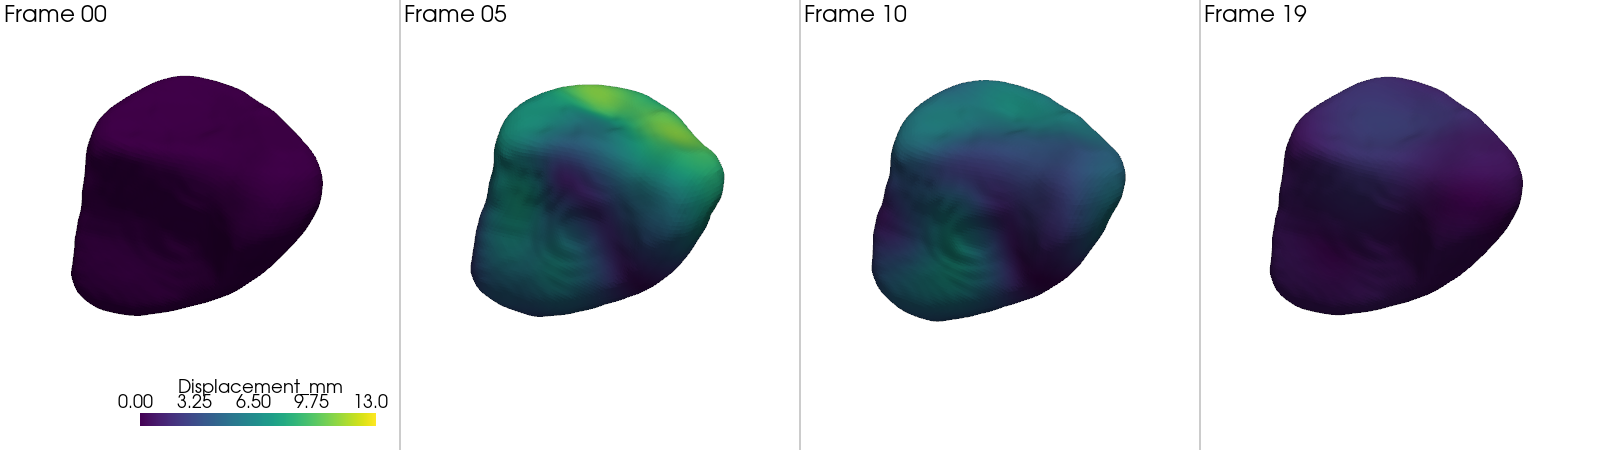

In [21]:
import pyvista as pv
import numpy as np

show_frames = [0, 5, 10, 19]

pv.set_jupyter_backend("static")

plotter = pv.Plotter(
    shape=(1, 4),
    notebook=True,
    window_size=(1600, 450)
)

reference = meshes[0].points

for panel, frame_id in enumerate(show_frames):

    mesh = meshes[frame_id].copy()

    displacement = np.linalg.norm(
        mesh.points - reference,
        axis=1
    )

    mesh["Displacement_mm"] = displacement

    plotter.subplot(0, panel)

    plotter.add_mesh(
        mesh,
        scalars="Displacement_mm",
        clim=[0, 13],
        show_edges=False
    )

    plotter.add_text(
        f"Frame {frame_id:02d}",
        font_size=10
    )

    plotter.view_isometric()

plotter.show()

In [27]:
from pathlib import Path

ROOT = Path("/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN")

print("Searching for MIRTK...")
for p in ROOT.rglob("mirtk"):
    if p.is_file():
        print(p)

Searching for MIRTK...
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/resources/binaries/bin/mirtk
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/resources/binaries/share/completion/bash/mirtk


In [29]:
from pathlib import Path
import subprocess
import os

ROOT = Path(
    "/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN"
)
SUBJECT = "subject_1"

MIRTK = ROOT / "resources" / "binaries" / "bin" / "mirtk"

# Bundled legacy libraries
LIB64 = ROOT / "resources" / "lib64"

motion_work = (
    ROOT / "results" / SUBJECT / "work" / SUBJECT / "motion"
)

mesh_dir = ROOT / "results" / SUBJECT / "mesh"
output_dir = ROOT / "results" / SUBJECT / "motion"
output_dir.mkdir(parents=True, exist_ok=True)

lv_ed = mesh_dir / "F_LVendo_ED.vtk"
lv_frame0 = output_dir / "LV_fr00.vtk"

# Environment for legacy MIRTK
env = os.environ.copy()
env["LD_LIBRARY_PATH"] = (
    str(LIB64)
    + ":"
    + env.get("LD_LIBRARY_PATH", "")
)

print("MIRTK:", MIRTK)
print("Library directory:", LIB64)
print("libpng12 exists:", (LIB64 / "libpng12.so.0").exists())
print("LV reference:", lv_ed)
print()

# Frame 00 = LV ED mesh
subprocess.run(
    ["cp", str(lv_ed), str(lv_frame0)],
    check=True
)

print("Creating LV motion sequence")
print("=" * 60)
print("Frame 00:", lv_frame0.name)

for fr in range(1, 20):

    dof = motion_work / f"ffd_00_to_{fr:02d}.dof.gz"
    out = output_dir / f"LV_fr{fr:02d}.vtk"

    if not dof.exists():
        raise FileNotFoundError(dof)

    subprocess.run(
        [
            str(MIRTK),
            "transform-points",
            str(lv_frame0),
            str(out),
            "-dofin",
            str(dof),
        ],
        check=True,
        env=env,
    )

    print(f"Frame {fr:02d}: {out.name}")

print("\n" + "=" * 60)
print("PASS: LV motion sequence generated")
print("=" * 60)

MIRTK: /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/resources/binaries/bin/mirtk
Library directory: /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/resources/lib64
libpng12 exists: True
LV reference: /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/mesh/F_LVendo_ED.vtk

Creating LV motion sequence
Frame 00: LV_fr00.vtk
Frame 01: LV_fr01.vtk
Frame 02: LV_fr02.vtk
Frame 03: LV_fr03.vtk
Frame 04: LV_fr04.vtk
Frame 05: LV_fr05.vtk
Frame 06: LV_fr06.vtk
Frame 07: LV_fr07.vtk
Frame 08: LV_fr08.vtk
Frame 09: LV_fr09.vtk
Frame 10: LV_fr10.vtk
Frame 11: LV_fr11.vtk
Frame 12: LV_fr12.vtk
Frame 13: LV_fr13.vtk
Frame 14: LV_fr14.vtk
Frame 15: LV_fr15.vtk
Frame 16: LV_fr16.vtk
Frame 17: LV_fr17.vtk
Frame 18: LV_fr18.vtk
Frame 19: LV_fr19.vtk

PASS: LV motion sequence generated


In [31]:
import pyvista as pv
import numpy as np

lv_files = sorted(output_dir.glob("LV_fr??.vtk"))
rv_files = sorted(output_dir.glob("RV_fr??.vtk"))

lv_meshes = [pv.read(str(f)) for f in lv_files]
rv_meshes = [pv.read(str(f)) for f in rv_files]

print("LV frames:", len(lv_meshes))
print("RV frames:", len(rv_meshes))

print("\nLV vertices:", lv_meshes[0].n_points)
print("LV cells:", lv_meshes[0].n_cells)

print("RV vertices:", rv_meshes[0].n_points)
print("RV cells:", rv_meshes[0].n_cells)

# Check correspondence
assert len(set(m.n_points for m in lv_meshes)) == 1
assert len(set(m.n_points for m in rv_meshes)) == 1

# Calculate displacement from frame 00
lv_ref = lv_meshes[0].points
rv_ref = rv_meshes[0].points

lv_mean, lv_max = [], []
rv_mean, rv_max = [], []

for lv, rv in zip(lv_meshes, rv_meshes):

    d_lv = np.linalg.norm(lv.points - lv_ref, axis=1)
    d_rv = np.linalg.norm(rv.points - rv_ref, axis=1)

    lv_mean.append(d_lv.mean())
    lv_max.append(d_lv.max())

    rv_mean.append(d_rv.mean())
    rv_max.append(d_rv.max())

print("\nPASS: LV and RV correspondence verified")

print(
    f"Peak LV mean displacement: "
    f"{max(lv_mean):.3f} mm "
    f"(Frame {np.argmax(lv_mean):02d})"
)

print(
    f"Peak RV mean displacement: "
    f"{max(rv_mean):.3f} mm "
    f"(Frame {np.argmax(rv_mean):02d})"
)

LV frames: 20
RV frames: 20

LV vertices: 21510
LV cells: 43016
RV vertices: 18028
RV cells: 36052

PASS: LV and RV correspondence verified
Peak LV mean displacement: 5.460 mm (Frame 07)
Peak RV mean displacement: 4.893 mm (Frame 07)


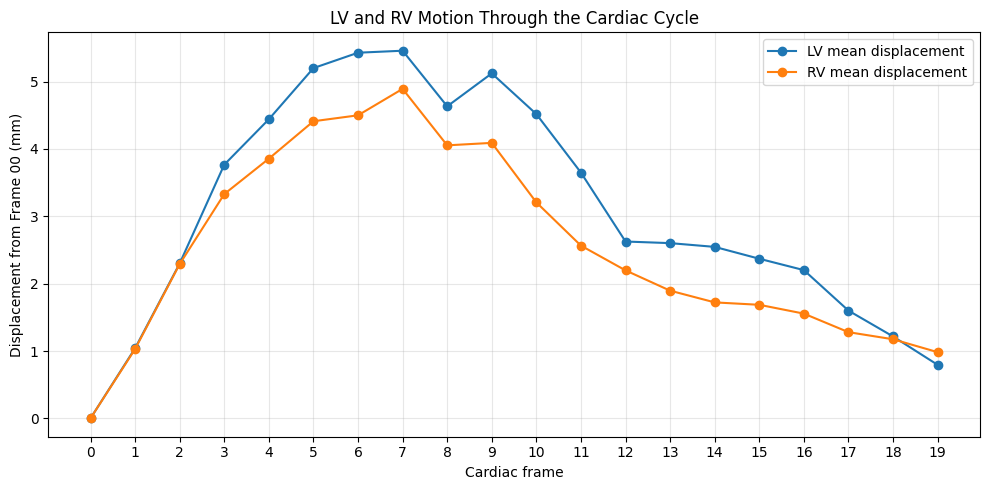

In [32]:
import matplotlib.pyplot as plt

frames = np.arange(20)

plt.figure(figsize=(10, 5))

plt.plot(
    frames, lv_mean,
    marker="o",
    label="LV mean displacement"
)

plt.plot(
    frames, rv_mean,
    marker="o",
    label="RV mean displacement"
)

plt.xlabel("Cardiac frame")
plt.ylabel("Displacement from Frame 00 (mm)")
plt.title("LV and RV Motion Through the Cardiac Cycle")
plt.xticks(frames)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

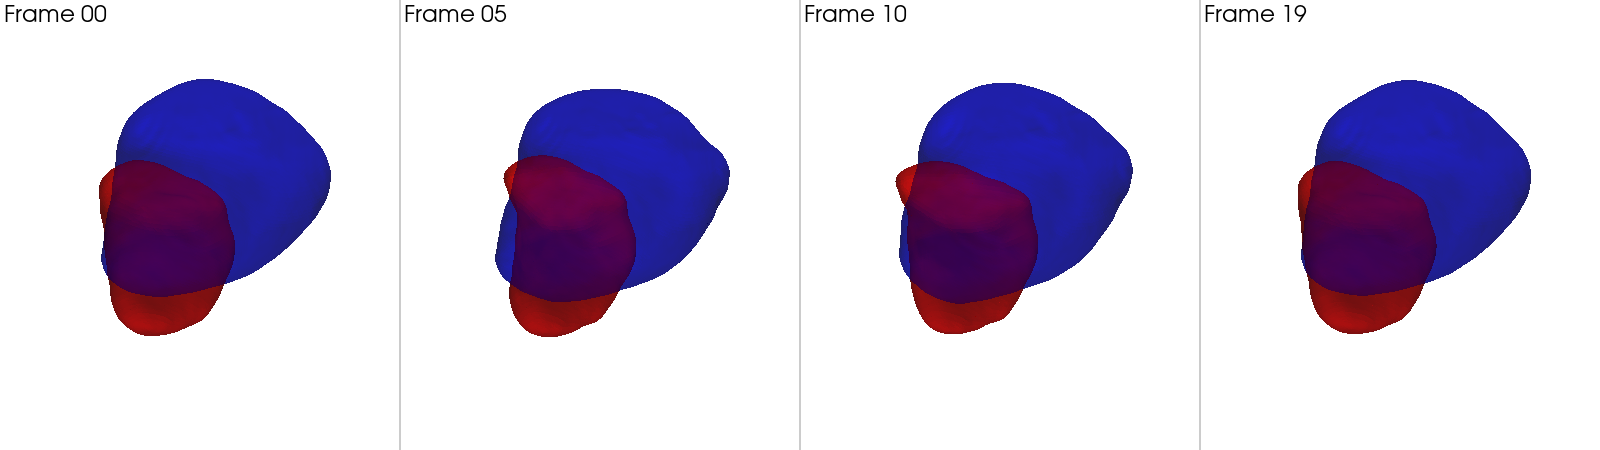

In [34]:
import pyvista as pv

show_frames = [0, 5, 10, 19]

pv.set_jupyter_backend("static")

plotter = pv.Plotter(
    shape=(1, 4),
    notebook=True,
    window_size=(1600, 450)
)

for panel, frame in enumerate(show_frames):

    plotter.subplot(0, panel)

    # LV
    plotter.add_mesh(
        lv_meshes[frame],
        color="red",
        opacity=0.75,
        show_edges=False,
        show_scalar_bar=False
    )

    # RV
    plotter.add_mesh(
        rv_meshes[frame],
        color="blue",
        opacity=0.65,
        show_edges=False,
        show_scalar_bar=False
    )

    plotter.add_text(
        f"Frame {frame:02d}",
        font_size=11
    )

    plotter.view_isometric()

plotter.show()

Displaying LV + RV motion
Number of frames: 20
Red  = LV endocardium
Blue = RV


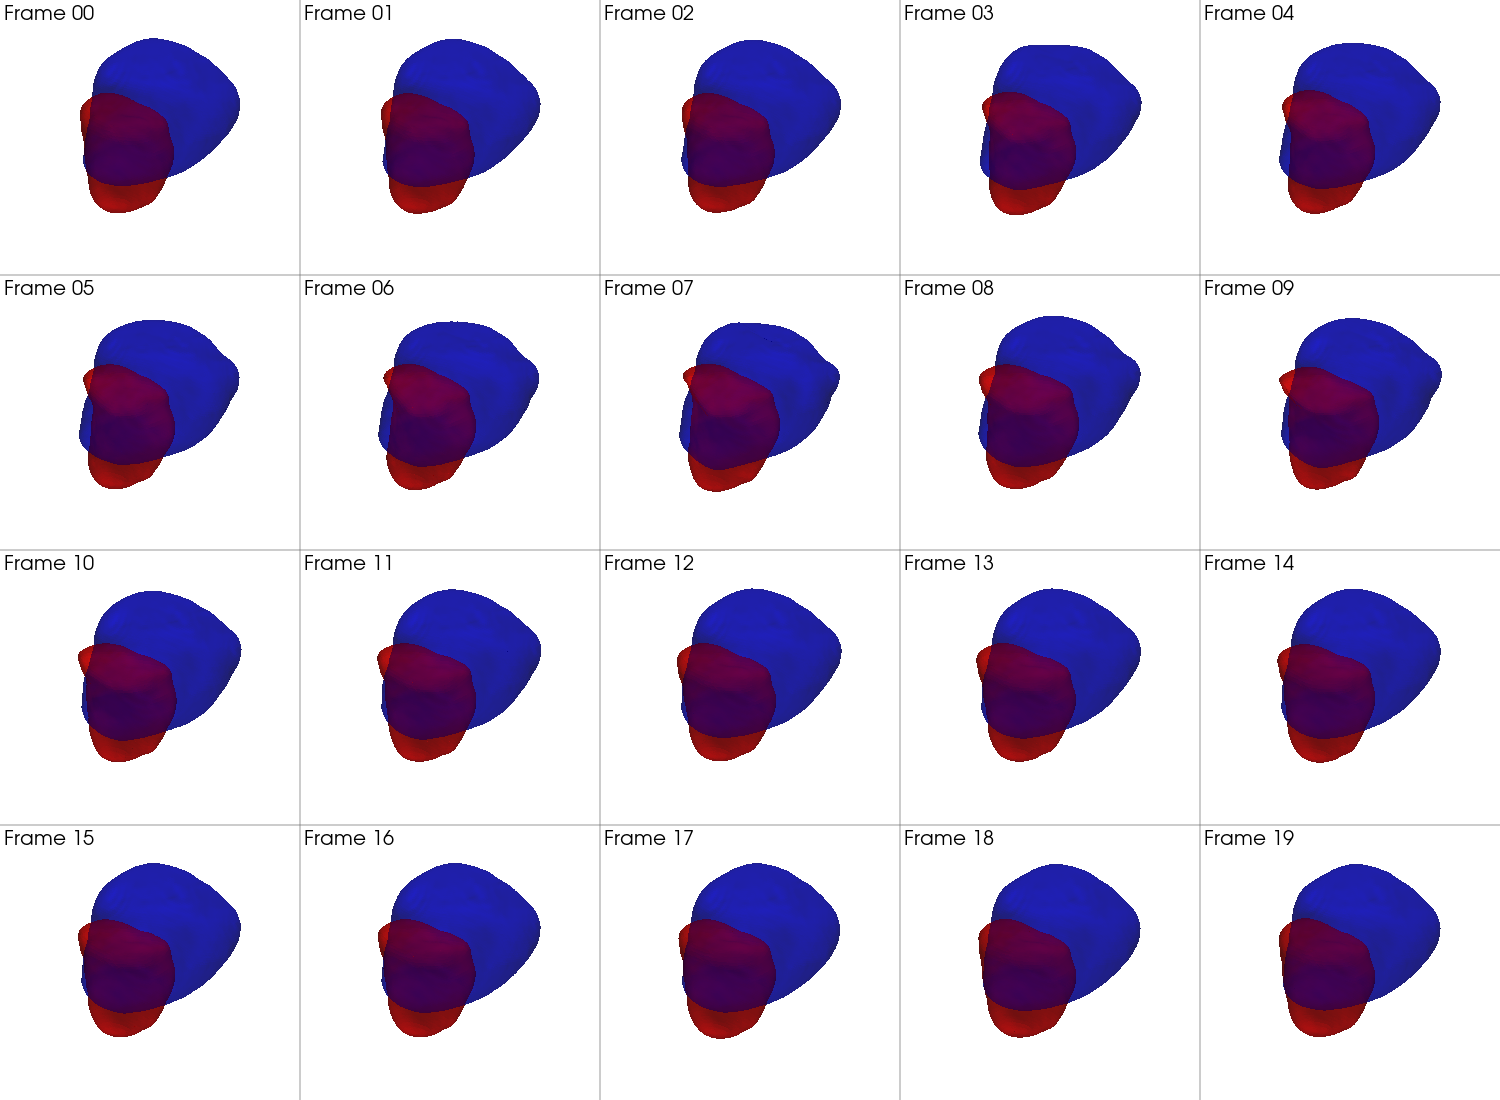

In [35]:
import pyvista as pv

# Display all 20 cardiac frames
n_frames = min(len(lv_meshes), len(rv_meshes))

print("Displaying LV + RV motion")
print("Number of frames:", n_frames)
print("Red  = LV endocardium")
print("Blue = RV")

pv.set_jupyter_backend("static")

# 4 rows × 5 columns = 20 frames
plotter = pv.Plotter(
    shape=(4, 5),
    notebook=True,
    window_size=(1500, 1100)
)

for frame in range(n_frames):

    row = frame // 5
    col = frame % 5

    plotter.subplot(row, col)

    # LV
    plotter.add_mesh(
        lv_meshes[frame],
        color="red",
        opacity=0.75,
        show_edges=False,
        show_scalar_bar=False
    )

    # RV
    plotter.add_mesh(
        rv_meshes[frame],
        color="blue",
        opacity=0.65,
        show_edges=False,
        show_scalar_bar=False
    )

    plotter.add_text(
        f"Frame {frame:02d}",
        font_size=10
    )

    plotter.view_isometric()

plotter.show()

In [36]:
import numpy as np
import pyvista as pv

n_frames = min(len(lv_meshes), len(rv_meshes))

# Reference coordinates at ED
lv_ref = lv_meshes[0].points.copy()
rv_ref = rv_meshes[0].points.copy()

for i in range(n_frames):

    # LV displacement
    lv_disp = np.linalg.norm(
        lv_meshes[i].points - lv_ref,
        axis=1
    )
    lv_meshes[i]["Displacement_mm"] = lv_disp

    # RV displacement
    rv_disp = np.linalg.norm(
        rv_meshes[i].points - rv_ref,
        axis=1
    )
    rv_meshes[i]["Displacement_mm"] = rv_disp

print("PASS: LV and RV displacement calculated")

PASS: LV and RV displacement calculated


In [37]:
print("Frame | LV mean | LV max | RV mean | RV max")
print("-" * 55)

for i in range(n_frames):

    lv_d = lv_meshes[i]["Displacement_mm"]
    rv_d = rv_meshes[i]["Displacement_mm"]

    print(
        f"{i:02d}    | "
        f"{lv_d.mean():7.3f} | "
        f"{lv_d.max():7.3f} | "
        f"{rv_d.mean():7.3f} | "
        f"{rv_d.max():7.3f}"
    )

Frame | LV mean | LV max | RV mean | RV max
-------------------------------------------------------
00    |   0.000 |   0.000 |   0.000 |   0.000
01    |   1.041 |   1.761 |   1.029 |   2.941
02    |   2.300 |   3.564 |   2.291 |   5.465
03    |   3.767 |   8.053 |   3.330 |   9.002
04    |   4.442 |   8.646 |   3.856 |   9.175
05    |   5.201 |  10.812 |   4.412 |  10.623
06    |   5.430 |  12.757 |   4.500 |  11.642
07    |   5.460 |  14.227 |   4.893 |  12.877
08    |   4.634 |  10.846 |   4.054 |   9.407
09    |   5.123 |  12.280 |   4.091 |   9.485
10    |   4.518 |   9.617 |   3.207 |   7.145
11    |   3.649 |   7.544 |   2.565 |   6.488
12    |   2.626 |   5.306 |   2.197 |   6.042
13    |   2.602 |   5.726 |   1.896 |   6.376
14    |   2.546 |   5.764 |   1.722 |   6.291
15    |   2.370 |   5.539 |   1.686 |   6.030
16    |   2.201 |   5.407 |   1.555 |   6.004
17    |   1.600 |   4.704 |   1.280 |   5.379
18    |   1.216 |   3.279 |   1.174 |   3.672
19    |   0.794 |   1.754 

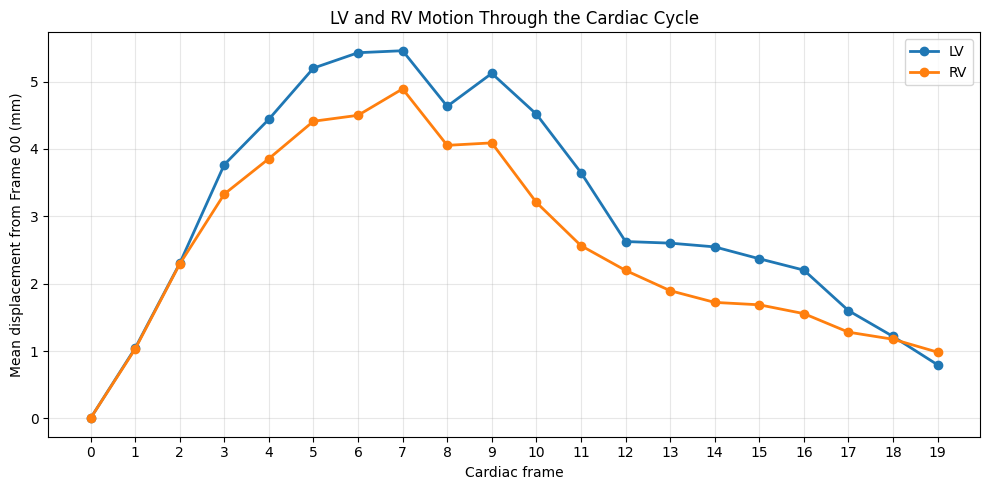

In [38]:
import numpy as np
import matplotlib.pyplot as plt

frames = np.arange(n_frames)

lv_mean = [
    np.mean(lv_meshes[i]["Displacement_mm"])
    for i in range(n_frames)
]

rv_mean = [
    np.mean(rv_meshes[i]["Displacement_mm"])
    for i in range(n_frames)
]

plt.figure(figsize=(10, 5))

plt.plot(
    frames,
    lv_mean,
    marker="o",
    linewidth=2,
    label="LV"
)

plt.plot(
    frames,
    rv_mean,
    marker="o",
    linewidth=2,
    label="RV"
)

plt.xlabel("Cardiac frame")
plt.ylabel("Mean displacement from Frame 00 (mm)")
plt.title("LV and RV Motion Through the Cardiac Cycle")

plt.xticks(frames)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

3-D LV + RV displacement visualization
Frame 00 : Reference
Frame 07 : Largest mean displacement
Frame 19 : Return toward reference
Common displacement range: 0 - 14.23 mm


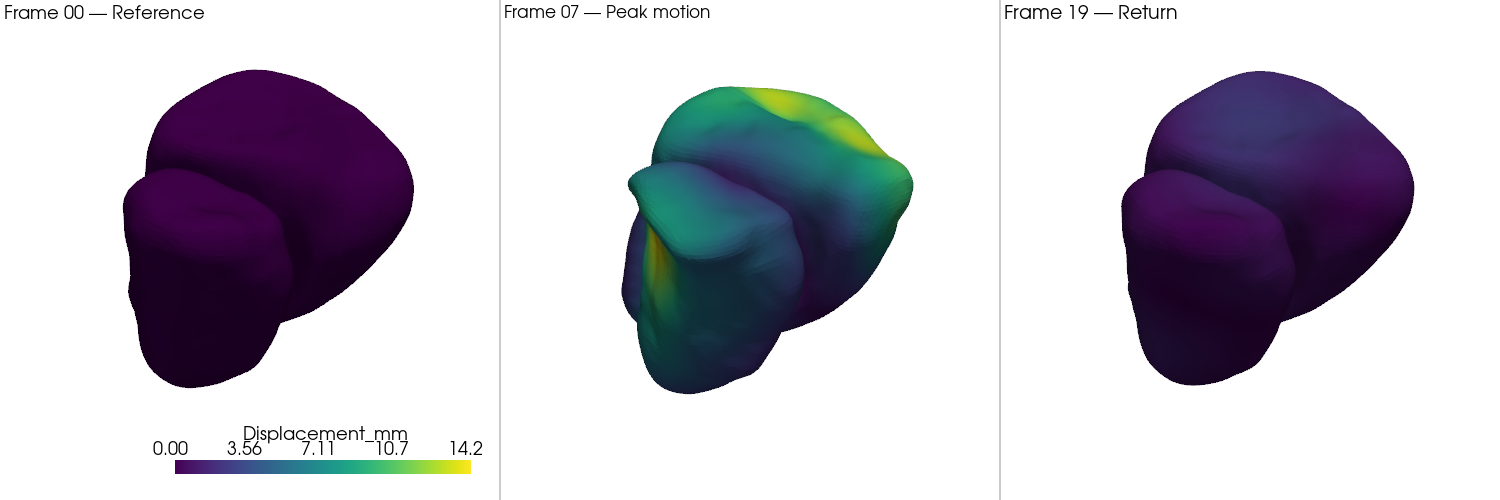

In [39]:
import numpy as np
import pyvista as pv

# Representative cardiac frames
show_frames = [0, 7, 19]

# Use the same displacement scale for every panel
all_max = []

for i in range(n_frames):
    all_max.append(lv_meshes[i]["Displacement_mm"].max())
    all_max.append(rv_meshes[i]["Displacement_mm"].max())

max_disp = max(all_max)

print("3-D LV + RV displacement visualization")
print("=" * 50)
print("Frame 00 : Reference")
print("Frame 07 : Largest mean displacement")
print("Frame 19 : Return toward reference")
print(f"Common displacement range: 0 - {max_disp:.2f} mm")

pv.set_jupyter_backend("static")

plotter = pv.Plotter(
    shape=(1, 3),
    notebook=True,
    window_size=(1500, 500)
)

for panel, frame in enumerate(show_frames):

    plotter.subplot(0, panel)

    # LV
    plotter.add_mesh(
        lv_meshes[frame],
        scalars="Displacement_mm",
        clim=[0, max_disp],
        cmap="viridis",
        show_edges=False,
        show_scalar_bar=(panel == 0)
    )

    # RV
    plotter.add_mesh(
        rv_meshes[frame],
        scalars="Displacement_mm",
        clim=[0, max_disp],
        cmap="viridis",
        show_edges=False,
        show_scalar_bar=False
    )

    if frame == 0:
        title = "Frame 00 — Reference"
    elif frame == 7:
        title = "Frame 07 — Peak motion"
    else:
        title = "Frame 19 — Return"

    plotter.add_text(
        title,
        font_size=11
    )

    plotter.view_isometric()

plotter.show()

## Optional — Run the Pipeline on Your Own Subject

During this practical we used prepared intermediate outputs because
segmentation, multi-atlas refinement, mesh fitting and motion estimation
are computationally expensive.

To process a new subject, provide a 4-D short-axis cine MRI and run
Steps 2–5 below.

The pipeline will produce:

- refined ED/ES cardiac segmentations
- fitted LV and RV meshes
- 20 LV motion meshes
- 20 RV motion meshes

The final motion meshes are stored in:

`results/<SUBJECT>/motion/`

> **Note:** Run these commands using the `4dsegment_py27` environment.

In [ ]:
import subprocess
from pathlib import Path

ROOT = Path(
    "/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN"
)

# ============================================================
# STUDENT INPUT — CHANGE ONLY THESE
# ============================================================

SUBJECT = "subject_2"
CINE = "example_20frames/subject_2_cine.nii"

CORES = 8

# ============================================================
# Check input
# ============================================================

cine_path = ROOT / CINE

if not cine_path.exists():
    raise FileNotFoundError(
        f"Cine MRI not found: {cine_path}"
    )

print("=" * 65)
print("PROCESSING NEW CARDIAC CINE SUBJECT")
print("=" * 65)
print("Subject:", SUBJECT)
print("Cine   :", cine_path)
print("Cores  :", CORES)

# ============================================================
# Commands
# ============================================================

commands = [

    # STEP 2
    [
        "python2",
        "scripts/02_segment.py",
        "--input", str(cine_path),
        "--subject", SUBJECT,
    ],

    # STEP 3
    [
        "python2",
        "scripts/03_refine.py",
        "--subject", SUBJECT,
        "--cores", str(CORES),
    ],

    # STEP 4
    [
        "python2",
        "scripts/04_create_mesh.py",
        "--subject", SUBJECT,
        "--cores", str(CORES),
    ],

    # STEP 5 — now produces BOTH LV + RV
    [
        "python2",
        "scripts/05_track_motion.py",
        "--subject", SUBJECT,
        "--cores", str(CORES),
    ],
]

names = [
    "Step 2 — ED/ES segmentation",
    "Step 3 — Multi-atlas refinement",
    "Step 4 — LV/RV mesh fitting",
    "Step 5 — LV/RV motion tracking",
]

# ============================================================
# Run pipeline
# ============================================================

for name, command in zip(names, commands):

    print("\n" + "=" * 65)
    print(name)
    print("=" * 65)

    subprocess.run(
        command,
        cwd=str(ROOT),
        check=True
    )

    print("PASS:", name)

# ============================================================
# Verify final motion outputs
# ============================================================

motion_dir = ROOT / "results" / SUBJECT / "motion"

lv = sorted(motion_dir.glob("LV_fr??.vtk"))
rv = sorted(motion_dir.glob("RV_fr??.vtk"))

print("\n" + "=" * 65)
print("FINAL OUTPUT")
print("=" * 65)

print("LV motion frames:", len(lv))
print("RV motion frames:", len(rv))

if len(lv) != 20:
    raise RuntimeError(
        f"Expected 20 LV frames, found {len(lv)}"
    )

if len(rv) != 20:
    raise RuntimeError(
        f"Expected 20 RV frames, found {len(rv)}"
    )

print("\nPASS: COMPLETE PIPELINE FINISHED")
print("20 LV + 20 RV motion meshes generated.")
print("\nOutput:")
print(motion_dir)

# Method 2: Motion Tracking Using Diffeomorphic Demons

In this method, cardiac motion is estimated directly from the cine MRI using **Diffeomorphic Demons registration** implemented with SimpleITK.

### Workflow

1. **Select the reference frame**
   - The end-diastolic (ED) frame is used as the reference configuration of the heart.
   - The LV surface mesh is extracted at ED.

2. **Register ED to each cardiac frame**
   - Diffeomorphic Demons registration is performed between the ED image and each frame of the cardiac cycle.
   - This produces a dense 3D displacement field describing how points move from the reference configuration.

3. **Propagate the LV mesh**
   - The displacement field is sampled at the LV mesh vertices.
   - Each ED vertex is displaced according to the estimated motion field.
   - This produces the tracked LV surface for every cardiac frame.

4. **Calculate displacement**
   - Vertex-wise displacement is calculated in millimetres relative to the ED reference mesh.
   - ED therefore has zero displacement.

5. **Visualize cardiac motion**
   - The tracked LV surfaces are displayed across the complete cardiac cycle.
   - Surface colour represents displacement magnitude.
   - The grey surface shows the ED reference shape for comparison.

### Output

The result is a sequence of 3D LV surfaces showing contraction from **ED → ES** and subsequent relaxation back toward ED.

**Important:** The computationally expensive Demons registration has already been performed.  
The following cells load and visualize the previously generated motion-tracking results.

In [8]:
%cd /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN

!python experiments/sitk_demons/02_track_motion_all_frames.py --subject subject_1

/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN
OPTIONAL EXPERIMENT - SIMPLEITK DEMONS
Subject      : subject_1
Cine         : /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/work/subject_1/lvsa_.nii.gz
LV ED mesh   : /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/mesh/F_LVendo_ED.vtk
Frames       : 20
Output       : /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/experiments/sitk_demons

Frame 00
Reference ED mesh
Mean displacement : 0.000 mm
Maximum displacement : 0.000 mm

-----------------------------------------------------------------
Frame 01 / 19
-----------------------------------------------------------------
Running Diffeomorphic Demons...
Metric           : 0.003962425739080001
Iterations       : 100
Mean displacement: 0.836 mm
Max displacement : 2.519 mm

-----------------------------------------------------------------
Frame 02 / 19
--------------------------------------------------------------

In [9]:
%cd /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN

!python experiments/sitk_demons/03_visualize_motion.py --subject subject_1

/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN
SIMPLEITK DEMONS MOTION VISUALIZATION
Subject : subject_1
Frames  : 20
Scale   : 0 - 10.970 mm
Saved montage:
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/experiments/sitk_demons/Demons_LV_20frames_montage.png

Saved animation:
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/subject_1/experiments/sitk_demons/Demons_LV_motion.gif

PASS: DEMONS MOTION VISUALIZATION SAVED


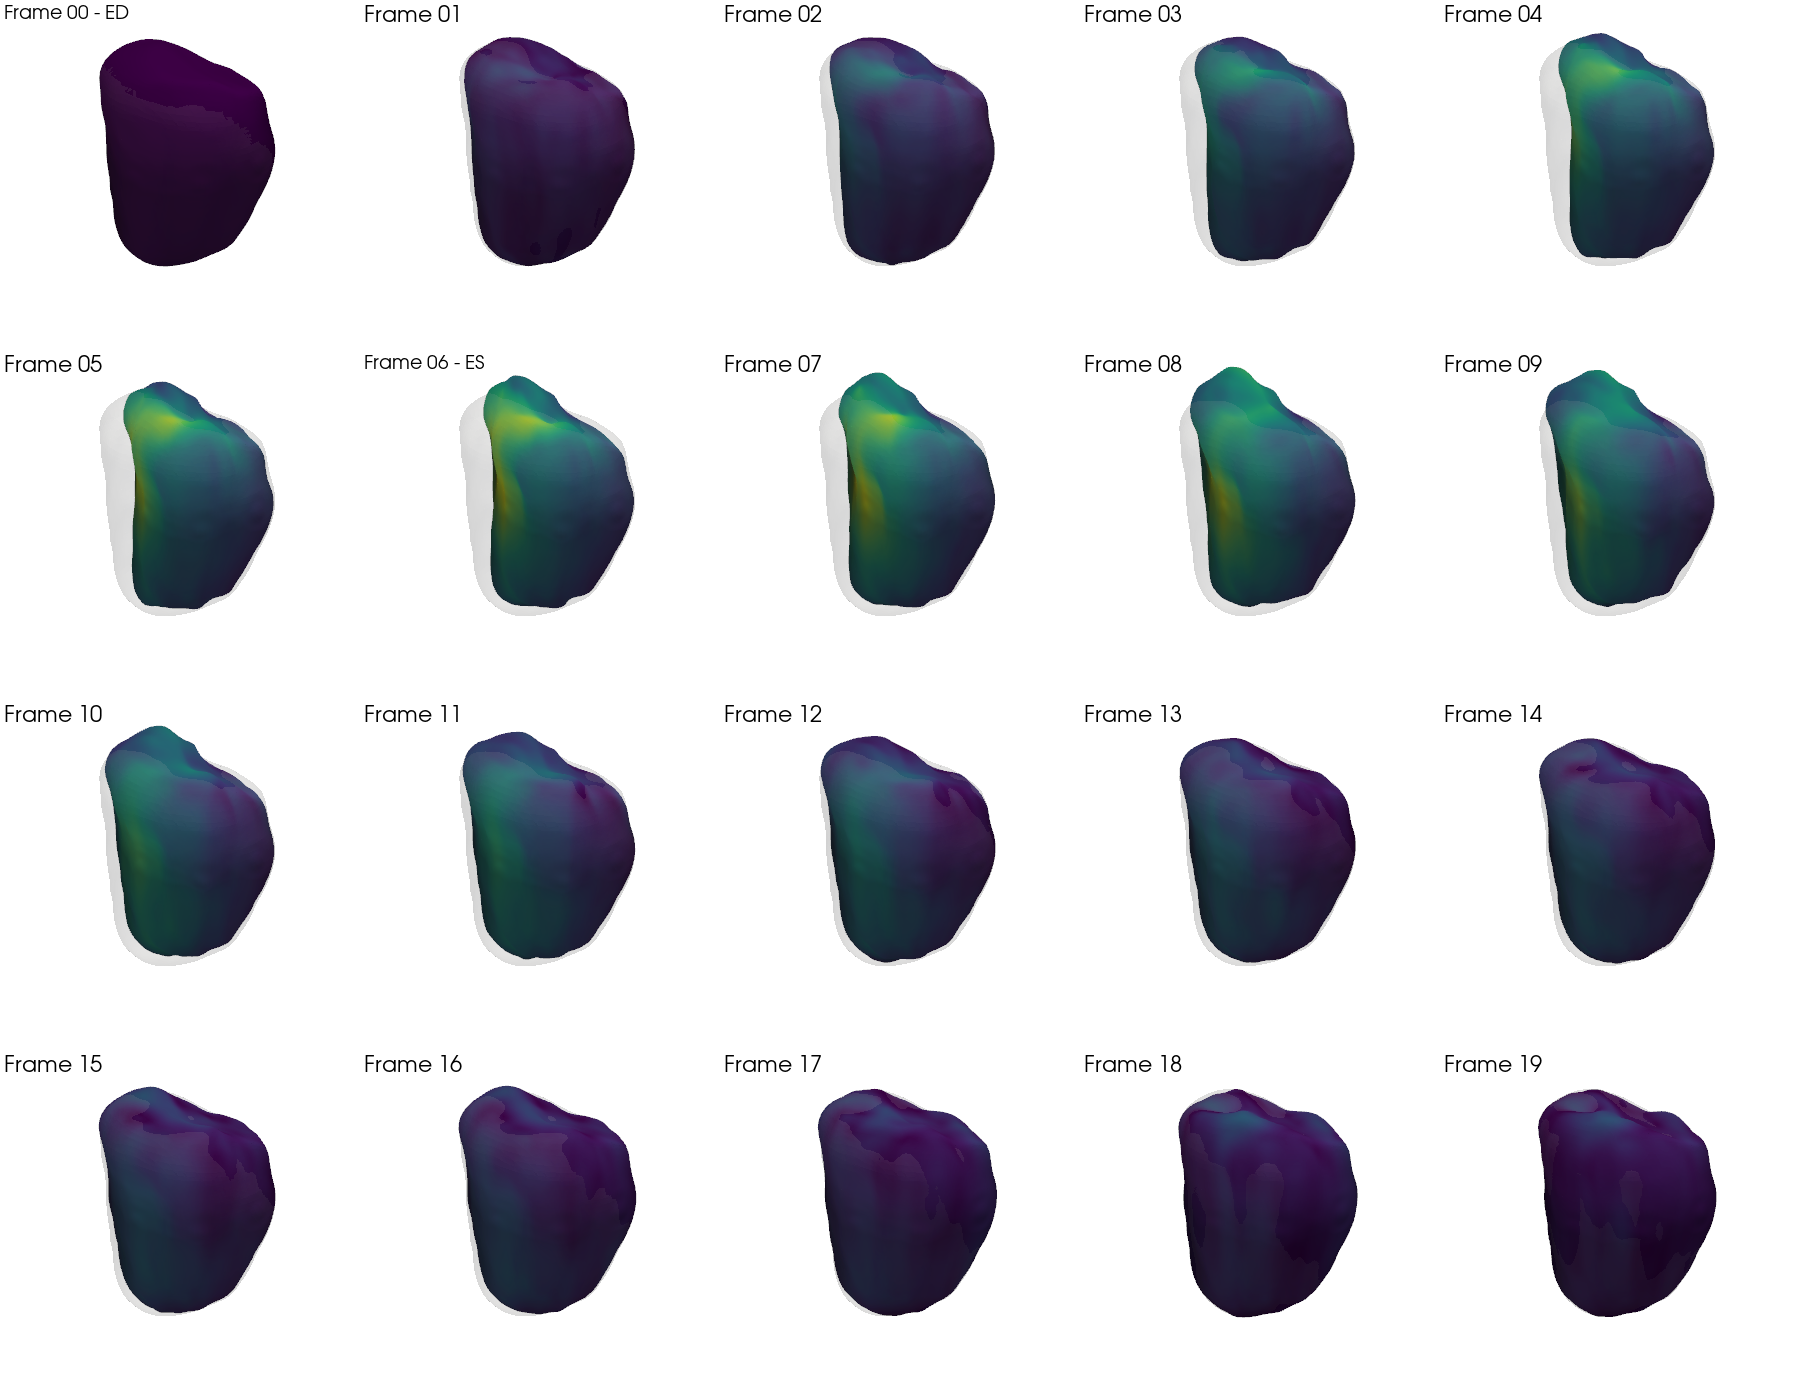

In [10]:
from IPython.display import Image, display

display(Image(
    filename="/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/"
             "results/subject_1/experiments/sitk_demons/"
             "Demons_LV_20frames_montage.png"
))

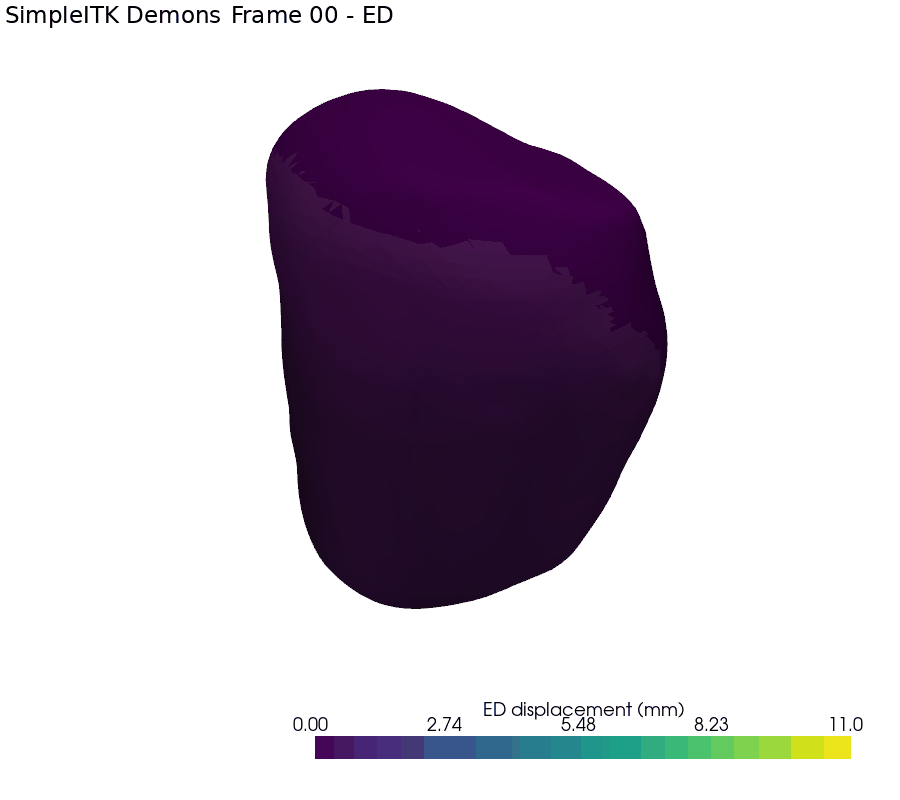

In [11]:
from IPython.display import Image, display

display(Image(
    filename="/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/"
             "results/subject_1/experiments/sitk_demons/"
             "Demons_LV_motion.gif"
))

# Method 3: Deep-Learning-Based Motion Tracking — CardioMorphNet

In this method, cardiac motion is estimated using **CardioMorphNet**, a deep-learning-based approach for learning cardiac shape and motion from cine MRI.

Unlike the previous registration-based methods, CardioMorphNet uses a trained neural network to estimate cardiac motion.

### Workflow

1. **Input cine MRI**
   - The complete cardiac cine sequence is used as input.
   - The sequence contains multiple frames covering the cardiac cycle from contraction to relaxation.

2. **Cardiac representation**
   - CardioMorphNet processes the cardiac images using its learned representation.
   - The model captures spatial cardiac anatomy together with changes occurring across the cardiac cycle.

3. **Motion estimation**
   - The trained model estimates how the cardiac anatomy deforms over time.
   - Motion is represented relative to the reference cardiac configuration.

4. **Propagate the LV surface**
   - The reference LV mesh is propagated through the cardiac cycle using the estimated motion.
   - This generates a corresponding LV surface for each cardiac frame.

5. **Calculate vertex displacement**
   - Displacement of each LV mesh vertex is measured relative to its reference position.
   - The displacement is expressed in millimetres.

6. **Visualize cardiac motion**
   - The resulting LV meshes are visualized over the complete cardiac cycle.
   - The reference surface and predicted surfaces can be compared to examine contraction and relaxation.

### Output

The result is a sequence of 3D LV meshes describing cardiac motion throughout the cardiac cycle.

This provides a **deep-learning alternative** to the conventional FFD and Diffeomorphic Demons registration approaches used in Methods 1 and 2.

**Important:** CardioMorphNet inference has already been performed.  
The following cells load and visualize the previously generated CardioMorphNet motion results.

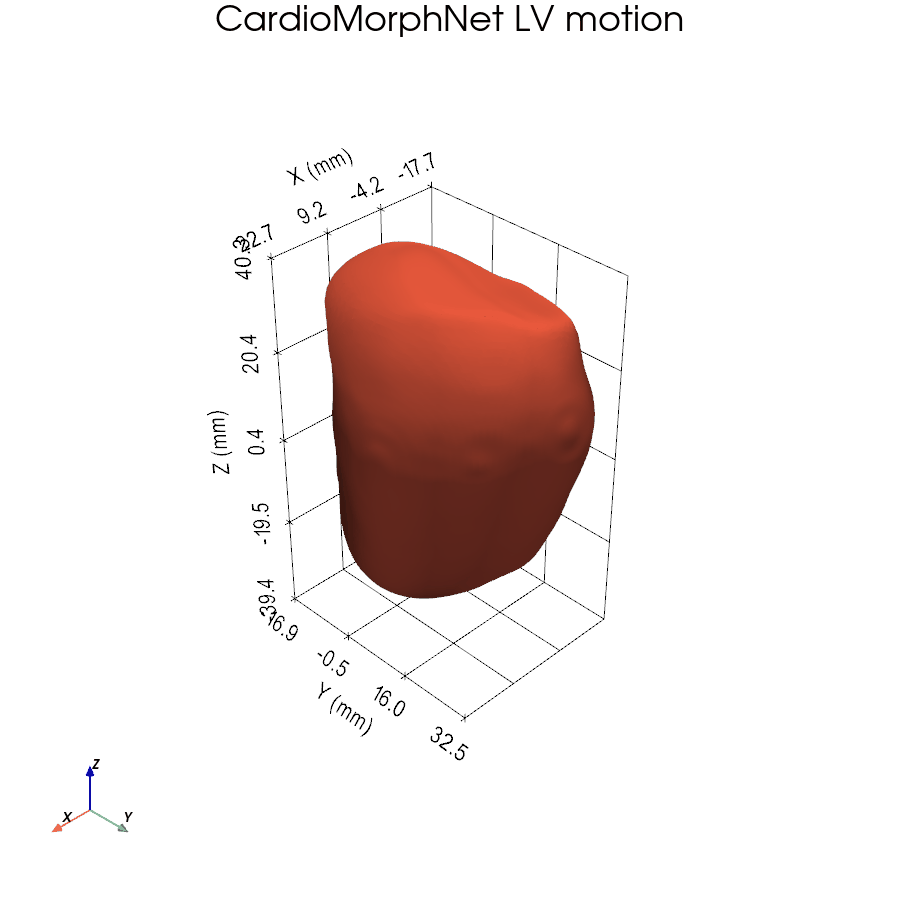

In [12]:
from IPython.display import Image, display

gif_file = (
    "/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/"
    "experiments/cardiomorphnet/upstream/subject1_mesh_motion/"
    "CardioMorphNet_LV_motion.gif"
)

display(Image(filename=gif_file))

Frames: 4
Saved: /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/experiments/cardiomorphnet/upstream/subject1_mesh_motion/CardioMorphNet_LV_motion_with_GT_SLOW.gif


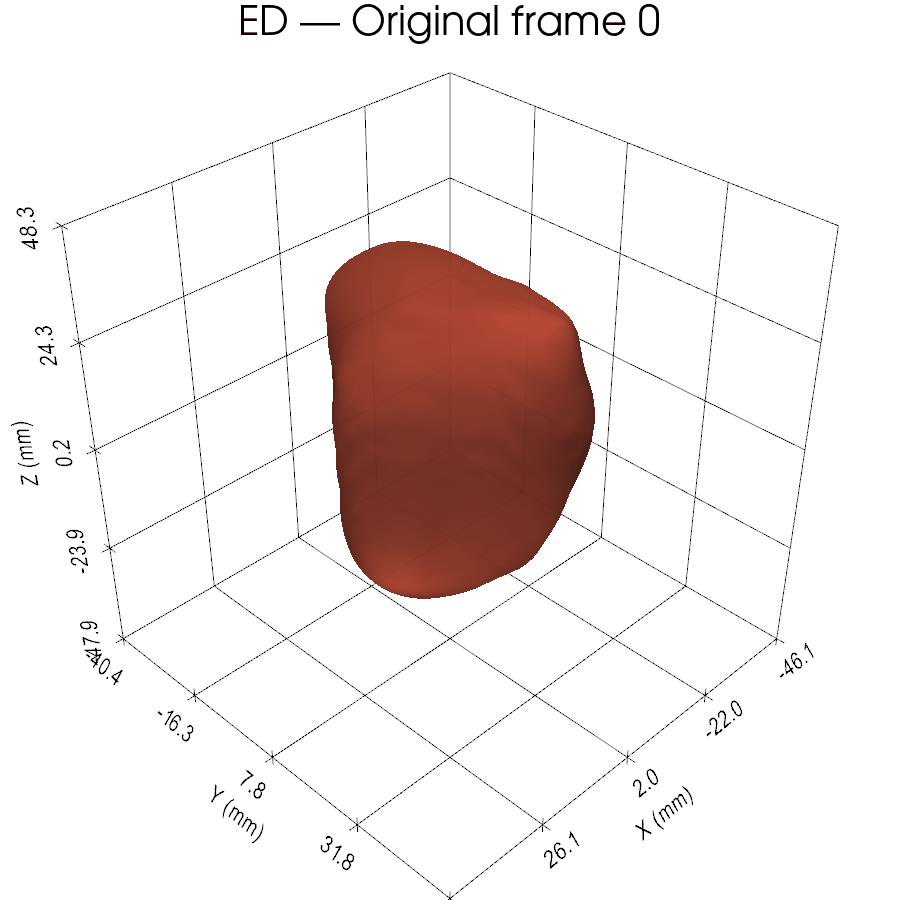

In [14]:
from PIL import Image
from IPython.display import Image as IPImage, display

input_gif = (
    "/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/"
    "experiments/cardiomorphnet/upstream/subject1_mesh_motion/"
    "CardioMorphNet_LV_motion_with_GT.gif"
)

output_gif = (
    "/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/"
    "experiments/cardiomorphnet/upstream/subject1_mesh_motion/"
    "CardioMorphNet_LV_motion_with_GT_SLOW.gif"
)

im = Image.open(input_gif)

frames = []
try:
    while True:
        frames.append(im.copy().convert("RGB"))
        im.seek(im.tell() + 1)
except EOFError:
    pass

# 800 ms per frame = 1.25 frames/second
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=800,
    loop=0
)

print("Frames:", len(frames))
print("Saved:", output_gif)

display(IPImage(filename=output_gif))

# ============================================================
# START
# ============================================================

ssh aqayyum@ic-rosa

cd /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN

conda activate cardiac_seg


# ============================================================
# STEP 1 — Check the input cine MRI
# ============================================================

python scripts/01_check_data.py \
  --input /data1/aqayyum/Mesh_analysis/datasets/CardioMorphNet_MnM/Testing/I4R8V6/I4R8V6_sa.nii.gz


# ============================================================
# STEP 2 — SEGMENT THE CINE
# ============================================================
# This is the expensive segmentation/preparation stage.
# It generates the segmentations required by the legacy
# mesh-fitting pipeline.

python scripts/02_segment.py \
  --input /data1/aqayyum/Mesh_analysis/datasets/CardioMorphNet_MnM/Testing/I4R8V6/I4R8V6_sa.nii.gz \
  --subject I4R8V6


# ============================================================
# STEP 3 — PREPARE ED/ES SEGMENTATIONS FOR MESH FITTING
# ============================================================
#
# This stage produces the files expected by meshfitting.py,
# including:
#
# results/I4R8V6/work/I4R8V6/
#       PHsegmentation_ED.gipl
#       PHsegmentation_ES.gipl
#
# Run:

python scripts/03_prepare_mesh.py \
  --subject I4R8V6


# Check them:

ls -lh \
  results/I4R8V6/work/I4R8V6/PHsegmentation_ED.gipl \
  results/I4R8V6/work/I4R8V6/PHsegmentation_ES.gipl


# ============================================================
# STEP 4 — FIT TEMPLATE MESH TO THIS SUBJECT
# ============================================================
#
# This is the computationally expensive mesh-fitting stage.
#
# Internally this performs:
#
# segmentation
#      ↓
# affine registration
#      ↓
# non-rigid registration
#      ↓
# template surface mapping
#      ↓
# subject-specific LV/RV meshes

conda activate 4dsegment_py27

export PATH=/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/resources/irtk_bin:$PATH

export LD_LIBRARY_PATH=/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/resources/lib64:${LD_LIBRARY_PATH}

python2 scripts/04_create_mesh.py \
  --subject I4R8V6 \
  --cores 8


# ============================================================
# STEP 5 — CHECK THE FINAL SUBJECT-SPECIFIC MESHES
# ============================================================

ls -lh results/I4R8V6/mesh/


# Expected important outputs:
#
# F_LVendo_ED.vtk
# F_LVendo_ES.vtk
# F_LVepi_ED.vtk
# F_LVepi_ES.vtk
# C_RV_ED.vtk
# C_RV_ES.vtk

# ============================================================
# 1. Login to the server
# ============================================================

ssh aqayyum@ic-rosa


# ============================================================
# 2. Go to the CardioMorphNet directory
# ============================================================

cd /data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/experiments/cardiomorphnet/upstream


# ============================================================
# 3. Activate the Python environment
# ============================================================

conda activate cardiac_seg


# ============================================================
# 4. Check that the subject data are available
# ============================================================

ls -lh /data1/aqayyum/Mesh_analysis/datasets/CardioMorphNet_MnM/Testing/I4R8V6/


# Expected important files include the cine MRI and segmentation:
#
# I4R8V6_sa.nii.gz
# I4R8V6_sa_gt.nii.gz


# ============================================================
# 5. Check that the fitted ED/ES meshes already exist
# ============================================================

ls -lh \
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/I4R8V6/mesh/F_LVendo_ED.vtk \
/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN/results/I4R8V6/mesh/F_LVendo_ES.vtk


# ============================================================
# 6. Run CardioMorphNet inference
# ============================================================

python infer_I4R8V6_cardiomorph.py


# Expected output includes:
#
# Original cine: (256, 256, 12, 25)
# Selected original frames: [24, 2, 5, 8, 13, 19]
# Network ED index: 0
# Network ES index: 3
#
# Running CardioMorphNet...
#
# Inference complete.
# DVF shape: (6, 3, 128, 128, 16)
#
# Results are saved in:
#
# I4R8V6_cardiomorph_results/
#     I4R8V6_cardiomorph_results.pkl


# ============================================================
# 7. Propagate the fitted ED mesh using the predicted DVFs
# ============================================================

python warp_I4R8V6_mesh.py


# For this subject the ED -> ES trajectory is:
#
# Frame 24 (ED)
#       ↓
# Frame 2
#       ↓
# Frame 5
#       ↓
# Frame 8 (ES)
#
# The script creates:
#
# I4R8V6_mesh_motion/
#     F_LVendo_frame_00_predicted.vtk
#     F_LVendo_frame_02_predicted.vtk
#     F_LVendo_frame_05_predicted.vtk
#     F_LVendo_frame_08_predicted.vtk
#     F_LVendo_ES_predicted.vtk


# ============================================================
# 8. Check the generated meshes
# ============================================================

ls -lh I4R8V6_mesh_motion/*.vtk


# ============================================================
# 9. Start Jupyter Notebook
# ============================================================

jupyter notebook --no-browser --port=8888


# Keep this SSH terminal running.
# Open the Jupyter URL/token in the browser.

# ============================================================
# CardioMorphNet: create subject-specific motion meshes
# Example subject: I4R8V6
# ============================================================

# STEP 1 — Inputs
#
# Cine MRI:
#   I4R8V6_sa.nii.gz
#
# 4D segmentation:
#   I4R8V6_sa_gt.nii.gz
#
# Subject-specific fitted ED mesh:
#   results/I4R8V6/mesh/F_LVendo_ED.vtk
#
# Subject-specific fitted ES mesh (used only as reference):
#   results/I4R8V6/mesh/F_LVendo_ES.vtk


# STEP 2 — Identify ED and ES
#
# For I4R8V6:
#
# ED = frame 24
# ES = frame 8
#
# CardioMorphNet temporal sampling selected:
#
# [24, 2, 5, 8, 13, 19]
#
# Therefore, for ED -> ES we use:
#
#       24  ->  2  ->  5  ->  8
#       ED                  ES


# STEP 3 — Run CardioMorphNet inference
#
# This predicts the deformation fields (DVFs)
# between the selected cardiac phases.
#
# Script used:
#
#   infer_I4R8V6_cardiomorph.py
#
# Main output:
#
#   I4R8V6_cardiomorph_results/
#       I4R8V6_cardiomorph_results.pkl
#
# DVF shape:
#   (6, 3, 128, 128, 16)


# STEP 4 — Start from the fitted ED LV mesh
#
# Initial mesh:
#
#   F_LVendo_ED.vtk
#
# It contains 21,510 corresponding vertices.


# STEP 5 — Propagate the ED mesh using CardioMorphNet DVFs
#
# Script used:
#
#   warp_I4R8V6_mesh.py
#
# Sequential propagation:
#
#   ED mesh (frame 24)
#          |
#          | DVF
#          v
#       frame 2
#          |
#          | DVF
#          v
#       frame 5
#          |
#          | DVF
#          v
#       frame 8 = ES


# STEP 6 — Generated meshes
#
# Output directory:
#
#   I4R8V6_mesh_motion/
#
# Generated meshes:
#
#   F_LVendo_frame_00_predicted.vtk   # ED
#   F_LVendo_frame_02_predicted.vtk
#   F_LVendo_frame_05_predicted.vtk
#   F_LVendo_frame_08_predicted.vtk   # ES
#   F_LVendo_ES_predicted.vtk         # final predicted ES


# STEP 7 — Visualisation
#
# Load the four propagated meshes with PyVista:
#
#   ED
#   Cardiac Phase 1
#   Cardiac Phase 2
#   ES
#
# For each vertex calculate:
#
#   displacement = || x_current - x_ED ||
#
# and display displacement in millimetres on the mesh.


# STEP 8 — Optional validation
#
# Compare:
#
#   CardioMorphNet predicted ES:
#       F_LVendo_ES_predicted.vtk
#
# against fitted ES reference:
#       results/I4R8V6/mesh/F_LVendo_ES.vtk
#
# For I4R8V6:
#
#   Symmetric mean surface distance = 4.03 mm
#   Symmetric 95th percentile       = 9.49 mm
#   Maximum surface distance        = 11.64 mm

# Deep Learning Motion Tracking — CardioMorphNet

## Example: I4R8V6

CardioMorphNet predicts dense deformation fields from cine MRI.
The predicted deformation is applied to the template-corresponded
end-diastolic LV mesh to track cardiac motion through the cardiac cycle.

In [1]:
import os
import pyvista as pv

ROOT = "/data1/aqayyum/Mesh_analysis/Motion_Alan_Turing_CLEAN"

MOTION_DIR = os.path.join(
    ROOT,
    "experiments/cardiomorphnet/upstream/I4R8V6_mesh_motion"
)

mesh_paths = {
    24: os.path.join(MOTION_DIR, "F_LVendo_frame_00_predicted.vtk"),
    2:  os.path.join(MOTION_DIR, "F_LVendo_frame_02_predicted.vtk"),
    5:  os.path.join(MOTION_DIR, "F_LVendo_frame_05_predicted.vtk"),
    8:  os.path.join(MOTION_DIR, "F_LVendo_frame_08_predicted.vtk"),
}

meshes = {}

for frame, path in mesh_paths.items():
    assert os.path.exists(path), "Missing: " + path
    meshes[frame] = pv.read(path)

    print(
        "Frame", frame,
        "| points:", meshes[frame].n_points,
        "| cells:", meshes[frame].n_cells
    )

/home/aqayyum/miniconda3/envs/cardiac_seg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Frame 24 | points: 21510 | cells: 43016
Frame 2 | points: 21510 | cells: 43016
Frame 5 | points: 21510 | cells: 43016
Frame 8 | points: 21510 | cells: 43016


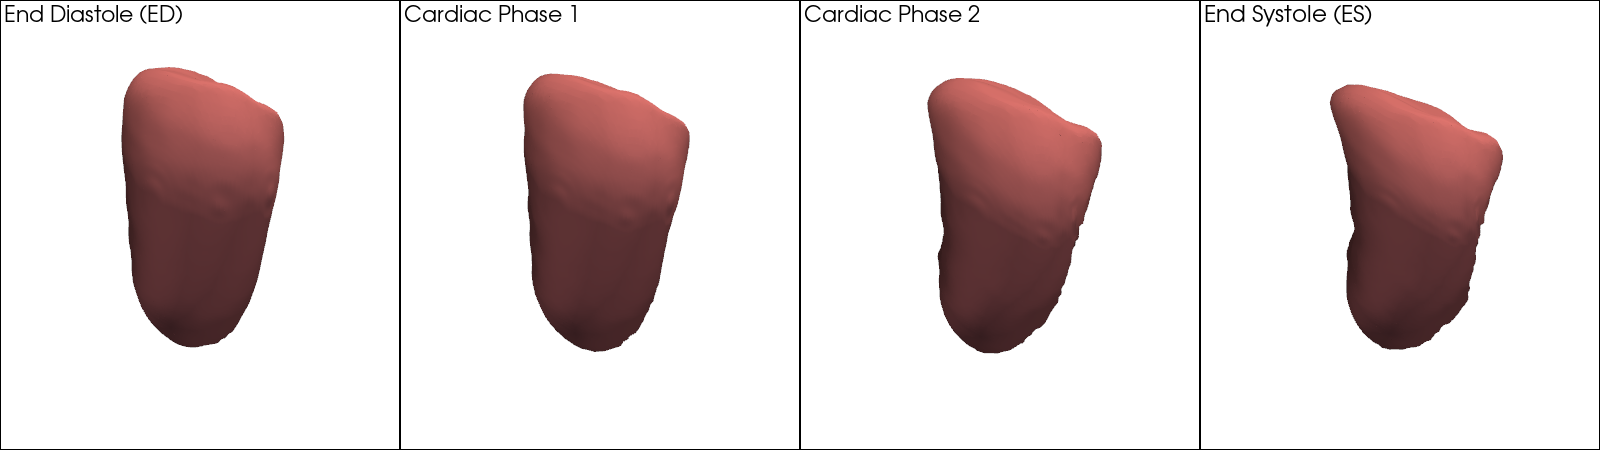

In [4]:
frames = [24, 2, 5, 8]

titles = [
    "End Diastole (ED)",
    "Cardiac Phase 1",
    "Cardiac Phase 2",
    "End Systole (ES)"
]

p = pv.Plotter(shape=(1, 4), notebook=True, window_size=(1600, 450))

for i, frame in enumerate(frames):

    p.subplot(0, i)

    p.add_mesh(
        meshes[frame],
        color="lightcoral",
        smooth_shading=True,
        show_edges=False,
        scalars=None
    )

    p.add_text(titles[i], font_size=12)

    p.camera_position = "iso"

p.link_views()
p.show(jupyter_backend="static")

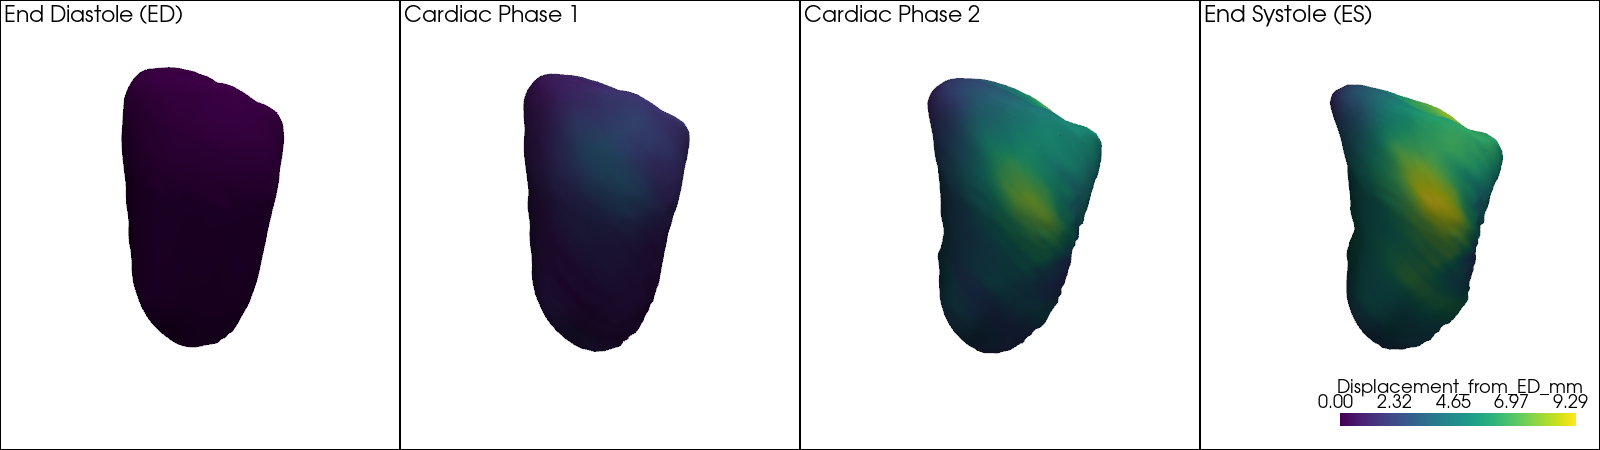

In [5]:
import numpy as np
import pyvista as pv

frames = [24, 2, 5, 8]
titles = [
    "End Diastole (ED)",
    "Cardiac Phase 1",
    "Cardiac Phase 2",
    "End Systole (ES)"
]

ed = meshes[24].points.copy()

# Calculate displacement from ED for every corresponding vertex
disp = {}

for frame in frames:
    disp[frame] = np.linalg.norm(
        meshes[frame].points - ed,
        axis=1
    )

# Common scale across all phases
vmax = max(d.max() for d in disp.values())

p = pv.Plotter(shape=(1, 4), notebook=True, window_size=(1600, 450))

for i, frame in enumerate(frames):

    p.subplot(0, i)

    m = meshes[frame].copy()
    m["Displacement_from_ED_mm"] = disp[frame]

    p.add_mesh(
        m,
        scalars="Displacement_from_ED_mm",
        clim=[0, vmax],
        smooth_shading=True,
        show_edges=False,
        show_scalar_bar=(i == 3)
    )

    p.add_text(titles[i], font_size=12)
    p.camera_position = "iso"

p.link_views()

p.show(jupyter_backend="static")